In [1]:
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv())

import warnings

warnings.filterwarnings("ignore")
import kairo


In [2]:
log = kairo.read_log("../data/control-flow.xes")
log = kairo.map_columns(log, {
    "case ID": "case:concept:name", "activity": "concept:name",
    "timestamp": "time:timestamp", "resource": "org:resource", "event duration": "event:duration_min",
})

parsing log, completed traces :: 100%|██████████████████████████████████████████████████████████████████████████████████| 5023/5023 [00:00<00:00, 15375.01it/s]


In [3]:
stats = kairo.log_statistics(log)
print(kairo.abstract_log_statistics(stats))

Event log statistics:
cases: 5023, events: 25511, activities: 8, resources: 7
time span: 2020-01-01 00:30:53.004000+00:00 → 2020-12-30 21:48:20.379992+00:00 (525437 minutes)
throughput time (days): min 0.00, mean 0.13, median 0.07, max 1.80
case length (events): min 1, mean 5.1, median 3.0, max 56
activity frequencies: a (7551), b (5066), g (2838), f (2820), c (2604), d (2462), e (1860), h (310)
resource frequencies: res_05 (10878), res_02 (3243), res_06 (2987), res_03 (2804), res_07 (2647), res_04 (2217), res_01 (735)


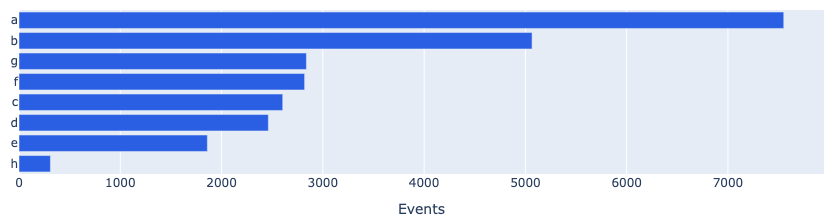

In [4]:
kairo.plot_activity_frequency(stats).show()

In [17]:
config = kairo.IntraConfig(
    features=("activity_freq", "bigram", "vocab", "progress", "current", "history"),
    clustering="som", grid=(5, 5), metric="euclidean",
    pca_components=12, window_minutes=1440 * 3,
    divergence="kl",
    reference="recent",
    lookback=8
)

result = kairo.run_intra_case(log, config)
result.to_dict()

{'perspective': 'intra_case',
 'config': {'features': ('activity_freq',
   'bigram',
   'vocab',
   'progress',
   'current',
   'history'),
  'history': 3,
  'skip_pca': False,
  'pca_components': 12,
  'scaling': 'none',
  'clustering': 'som',
  'metric': 'euclidean',
  'grid': (5, 5),
  'som_init': 'random',
  'n_clusters': 6,
  'eps': 0.5,
  'min_samples': 5,
  'window_minutes': 4320,
  'divergence': 'kl',
  'reference': 'recent',
  'lookback': 8,
  'seed': 7},
 'rows': 25511,
 'feature_columns': 68,
 'pca_components': 12,
 'n_states': 25,
 'method': 'som',
 'transitions': 20488,
 'windows': 122}

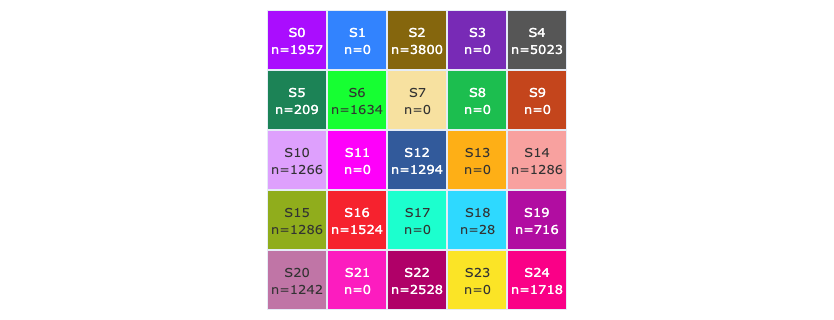

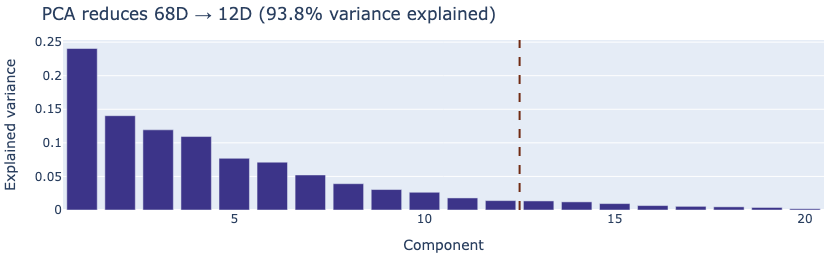

In [18]:
kairo.plot_state_grid(result.states).show()
kairo.plot_pca_variance(result.pca).show()

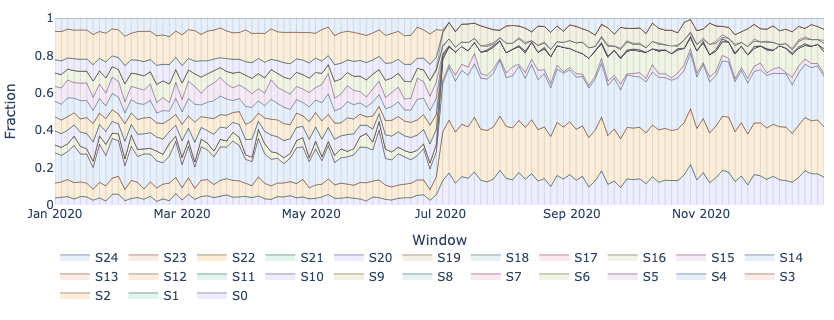

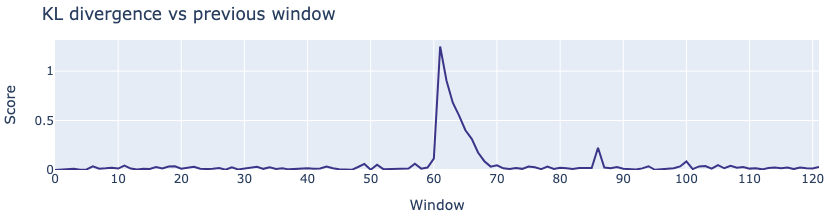

In [19]:
dist_fig = kairo.plot_state_distribution(result.distribution, result.states)
kairo.add_window_boundaries(dist_fig, result.distribution["window_start"])
dist_fig.show()
signal_fig = kairo.plot_drift_signal(result.signal, title="KL divergence vs previous window")
signal_fig.show()   # the drift point at 60% should stand out


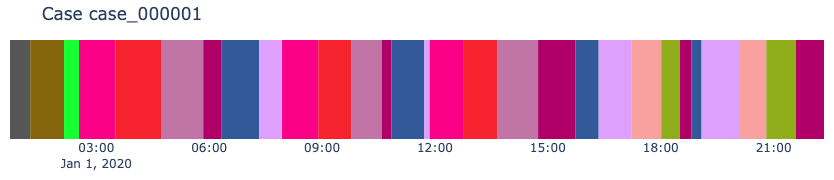

In [20]:
case = result.trajectories["case:concept:name"].iloc[2]
sub = result.trajectories[result.trajectories["case:concept:name"] == case]
kairo.plot_trajectory(sub["time:timestamp"], sub["state_id"].to_numpy(), result.states,
                      title=f"Case {case}").show()


In [21]:
profiles = kairo.analysis.state_profiles(result.features, result.states)
print(kairo.abstract_states(result.states, profiles=profiles, max_len=1200))

States from som (5×5 grid), parameters {'grid': (5, 5), 'metric': 'euclidean', 'init': 'random', 'epochs': 5, 'seed': 7}:
- S0: 1957 samples (7.7%), dominant: c
- S1: 0 samples (0.0%)
- S2: 3800 samples (14.9%), dominant: b
- S3: 0 samples (0.0%)
- S4: 5023 samples (19.7%), dominant: a
- S5: 209 samples (0.8%), dominant: e
- S6: 1634 samples (6.4%), dominant: d
- S7: 0 samples (0.0%)
- S8: 0 samples (0.0%)
- S9: 0 samples (0.0%)
- S10: 1266 samples (5.0%), dominant: c
- S11: 0 samples (0.0%)
- S12: 1294 samples (5.1%), dominant: b
- S13: 0 samples (0.0%)
- S14: 1286 samples (5.0%), dominant: f
- S15: 1286 samples (5.0%), dominant: g
- S16: 1524 samples (6.0%), dominant: f
- S17: 0 samples (0.0%)
- S18: 28 samples (0.1%), dominant: h
- S19: 716 samples (2.8%), dominant: g
- S20: 1242 samples (4.9%), dominant: g
- S21: 0 samples (0.0%)
- S22: 2528 samples (9.9%), dominant: a
- S23: 0 samples (0.0%)
- S24: 1718 samples (6.7%), dominant: e
Distinguishing features per state (deviation from 

In [22]:
print(kairo.abstract_result(result))

=== intra_case pipeline run ===

IntraConfig parameters:
- features: ('activity_freq', 'bigram', 'vocab', 'progress', 'current', 'history')
- history: 3
- skip_pca: False
- pca_components: 12
- scaling: none
- clustering: som
- metric: euclidean
- grid: (5, 5)
- som_init: random
- n_clusters: 6
- eps: 0.5
- min_samples: 5
- window_minutes: 4320
- divergence: kl
- reference: recent
- lookback: 8
- seed: 7

intra_case feature matrix: 25511 rows × 68 columns.
- activity_freq (Activity frequencies): 8 columns
- bigram (Directly-follows counts): 19 columns
- vocab (Distinct activity set): 8 columns
- progress (Case progress): 1 columns
- current (Current activity): 8 columns
- history (Past activities): 24 columns
Column ranges (min → max, mean):
  activity_freq:a: 0.167 → 1.000, mean 0.436
  activity_freq:b: 0.000 → 0.500, mean 0.228
  activity_freq:c: 0.000 → 0.333, mean 0.067
  activity_freq:d: 0.000 → 0.333, mean 0.079
  activity_freq:e: 0.000 → 0.333, mean 0.049
  activity_freq:f: 0.00

In [23]:
# Inspect the prompt without any network call
prompt = kairo.build_prompt("Where does the process drift, and what changes?",
                                result=result, log=log)
print(prompt)


<knowledge>
The analysis studies state-based concept drift detection in traditional event logs.
A process is monitored through three complementary notions of state:
- Intra-case state: the situation of one running case, derived from its event prefix
  (executed activities, their order, position in the case).
- Resource state: how the resource dimension behaves across all cases in a calendar
  window (workload, handovers, waiting times, activity-resource assignments).
- Inter-case state: the global process situation per calendar window (active cases,
  arrivals, completions, pacing, stalled cases, case-attribute mixes).
Concept drift means the underlying process changed over time. The core idea: compute
states by clustering feature vectors, follow how state occupancy evolves over calendar
windows, and read significant changes in those state signals as drift indicators.
A good analysis names WHERE the signal spikes (which windows), WHAT changed (which
states grew or shrank, which feature

In [24]:
QUESTION = "Does this analysis show concept drift? Name the windows, the states involved, and your confidence."

In [25]:
# Local models
print(kairo.llm.available_models("local"))

['google/gemma-4-e4b', 'meta/llama-3.3-70b', 'text-embedding-nomic-embed-text-v1.5']


In [26]:
answer = kairo.ask(QUESTION, result=result, log=log, executor=kairo.local_query)
print(answer)


Based on the analysis provided, **yes, concept drift is strongly indicated.**

The detection mechanism (KL divergence) shows a significant spike in the divergence score at specific windows, indicating that the feature profile of those time periods deviated dramatically from the immediately preceding historical window patterns.

Here is a detailed breakdown naming the location, the nature of the change, and the confidence level.

---

### 🟢 WHERE: The Windows of Drift

The concept drift signal shows multiple spikes, but the most pronounced evidence lies in **Window 61**.

*   **Primary Drift Window:** Window 61 (starting 2020-07-02).
    *   Score: $\text{1.248}$ (This is vastly higher than the mean score of 0.057, indicating a major structural shift.)
*   **Secondary/Sustained Drift:** The drift signal remains elevated in subsequent weeks, notably through Window 62 ($\text{0.904}$) and continuing at an increased level through Window 63 ($\text{0.680}$), suggesting the initial spike was

Based on the provided analysis, **yes, this analysis strongly shows evidence of concept drift.**

The diagnostic plots show an extreme spike in the divergence score precisely at Window 26, followed by several consecutive windows that remain significantly elevated compared to the historical baseline.

---

### 🚩 Concept Drift Summary

**1. Does concept drift exist?**
Yes. The process undergoes a significant and abrupt shift starting around **Window 26**.

**2. When did it occur (WHERE)?**
The primary spike occurs at:
*   **Window 26:** Starting `2020-07-01 00:30:53.004000` with a score of **1.834**. This is the most significant indicator.

This initial sudden drift (Window 26) is followed by sustained elevated scores, suggesting that the process did not immediately revert to its previous steady state:
*   **Window 27:** Score $0.924$
*   **Window 28:** Score $0.733$
*   **Window 29:** Score $0.511$
*   **Window 30:** Score $0.383$

The pattern suggests a **sudden shift** (at W26) that was followed by an **incremental or gradual deviation** from the previous normal operational rhythm over the next few weeks.

**3. What changed (WHAT)?**
Since this is an intra-case state model, "what" changed refers to the underlying feature composition of case prefixes reaching a new state distribution.

*   **Feature Drift:** The jump in divergence at Window 26 indicates that the characteristics defining running cases (the combination of `activity_freq`, `bigram` counts, `vocab` size, etc.) suddenly became statistically distinct from what was previously observed in the model's training data.
*   **State Drift:** While the report does not explicitly identify the specific states dominant at Window 26, the high score confirms that the *aggregate distribution* of feature vectors used to calculate state probabilities shifted significantly. The process began entering a population of cases defined by features different from those dominating the previous windows (e.g., if the prior normal operation was heavily characterized by `bigram:a→b` and low `vocab`, the drift window might show high values in other, previously rare bigrams).

**4. How confident is this evidence?**
The confidence level is **High**.

*   **Evidence:** The divergence score (1.834) is dramatically higher than the surrounding scores, which are mostly below $0.02$. This magnitude difference provides very strong statistical evidence that the underlying process has changed.
*   **Interpretation:** The consistent decline from W26 through W30 suggests a persistent deviation rather than a single spurious measurement spike, further reinforcing the finding of concept drift.
*   

### Hosted providers


In [27]:
answer = kairo.ask(QUESTION, result=result, log=log,
                       executor=kairo.anthropic_query, model="claude-sonnet-5")
print(answer)


## Verdict: Yes — a clear drift signal, most consistent with a **sudden shift** centered on window 61

### WHERE the signal spikes

The score series is flat noise (mean 0.057, mostly 0.01–0.04) until it suddenly jumps by roughly **20× the baseline**:

| window | start date | score |
|---|---|---|
| 60 | (pre-spike) | 0.115 |
| **61** | **2020-07-02** | **1.248** ← peak |
| 62 | 2020-07-05 | 0.904 |
| 63 | 2020-07-08 | 0.680 |
| 64 | 2020-07-11 | 0.550 |
| 65 | 2020-07-14 | 0.402 |

The monotonic decay over windows 62–65 is diagnostic, not incidental: with `reference="recent"` and `lookback=8`, each window is scored against the mean of the last 8 windows. A single abrupt change at window 61 will keep contaminating that rolling reference for ~8 subsequent windows, producing exactly this smeared, decaying tail rather than a sustained plateau. That pattern argues for a **one-time sudden change**, not gradual/incremental drift — a genuinely gradual process would show a *rising*, sustained b

In [ ]:
# Explain a plot
explanation = kairo.explain_plot(signal_fig, "What does this drift signal show? Where would you place the drift?",
                                     result=result, executor=kairo.anthropic_query, model="claude-sonnet-5")
print(explanation)


In [ ]:
cfg = kairo.nlp_to_config(
    "look for drift at weekly granularity with DBSCAN and a fairly tight eps, cosine distance",
    perspective="intra_case", executor=kairo.anthropic_query,
)
print(cfg)
kairo.run_intra_case(log, cfg)  # …and run it
